# Portfolio 1: Exploratory Data Analysis (EDA) on Tetouan City Power Consumption

This notebook conducts an in-depth exploratory data analysis and data quality assessment on the **Power Consumption of Tetouan City** dataset.

---

## Task 1: Loading & Initial Exploration (Hotfix)
- Load the Tetouan City CSV using `pandas`
- Convert `DateTime` column to a datetime object (feature extraction deferred to subsequent feature engineering steps)
- Output `df.shape` (expected: `(52416, 9)`), `df.head()`, `df.dtypes`, `df.describe()`, and `df.isnull().sum()`

In [50]:
import os
import pandas as pd
from IPython.display import display

# 1. Load the Tetouan City CSV using pandas
data_path = 'data/Tetuan City power consumption.csv'
if not os.path.exists(data_path):
    data_path = 'portfolio/data/Tetuan City power consumption.csv'

df = pd.read_csv(data_path)

# 2. Convert DateTime column to datetime object
df['DateTime'] = pd.to_datetime(df['DateTime'])

# 3. Output required initial diagnostics
print("=== 1. DataFrame Shape (df.shape) ===")
print(f"Shape: {df.shape} (rows, columns)\n")

print("=== 2. First 5 Rows (df.head()) ===")
display(df.head())

print("\n=== 3. Data Types (df.dtypes) ===")
display(df.dtypes)

print("\n=== 4. Statistical Summary (df.describe()) ===")
display(df.describe())

print("\n=== 5. Missing Values Count (df.isnull().sum()) ===")
display(df.isnull().sum())

=== 1. DataFrame Shape (df.shape) ===
Shape: (52416, 9) (rows, columns)

=== 2. First 5 Rows (df.head()) ===


,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964



=== 3. Data Types (df.dtypes) ===


DateTime                     datetime64[us]
Temperature                         float64
Humidity                            float64
Wind Speed                          float64
general diffuse flows               float64
diffuse flows                       float64
Zone 1 Power Consumption            float64
Zone 2  Power Consumption           float64
Zone 3  Power Consumption           float64
dtype: object


=== 4. Statistical Summary (df.describe()) ===


,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
count,52416,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,2017-07-01 23:55:00,18.810024,68.259518,1.959489,182.696614,75.028022,32344.970564,21042.509082,17835.406218
min,2017-01-01 00:00:00,3.247000,11.340000,0.050000,0.004000,0.011000,13895.696200,8560.081466,5935.174070
25%,2017-04-01 23:57:30,14.410000,58.310000,0.078000,0.062000,0.122000,26310.668692,16980.766032,13129.326630
50%,2017-07-01 23:55:00,18.780000,69.860000,0.086000,5.035500,4.456000,32265.920340,20823.168405,16415.117470
75%,2017-09-30 23:52:30,22.890000,81.400000,4.915000,319.600000,101.000000,37309.018185,24713.717520,21624.100420
max,2017-12-30 23:50:00,40.010000,94.800000,6.483000,1163.000000,936.000000,52204.395120,37408.860760,47598.326360
std,NaN,5.815476,15.551177,2.348862,264.400960,124.210949,7130.562564,5201.465892,6622.165099



=== 5. Missing Values Count (df.isnull().sum()) ===


DateTime                     0
Temperature                  0
Humidity                     0
Wind Speed                   0
general diffuse flows        0
diffuse flows                0
Zone 1 Power Consumption     0
Zone 2  Power Consumption    0
Zone 3  Power Consumption    0
dtype: int64

## Task 2: Data Quality Assessment
- Clean column headers (strip whitespace, fix double spaces in `'Zone 2  Power Consumption'` and `'Zone 3  Power Consumption'`, standardize into `snake_case`)
- Generate a missing values percentage table and seaborn missingness heatmap
- Detect duplicate rows
- Create a grid of boxplots for the 5 original numerical predictors and the 3 target zones (without removing outliers)

In [51]:
print("Raw column names:")
print(df.columns.tolist())

# Step 1: Strip leading/trailing spaces and collapse double spaces into single spaces
df.columns = df.columns.str.strip().str.replace('  ', ' ')

# Step 2: Standardize column names into snake_case
df.columns = df.columns.str.replace(' ', '_').str.lower()

print("\nStandardized column names (snake_case):")
print(df.columns.tolist())

Raw column names:
['DateTime', 'Temperature', 'Humidity', 'Wind Speed', 'general diffuse flows', 'diffuse flows', 'Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']

Standardized column names (snake_case):
['datetime', 'temperature', 'humidity', 'wind_speed', 'general_diffuse_flows', 'diffuse_flows', 'zone_1_power_consumption', 'zone_2_power_consumption', 'zone_3_power_consumption']


=== Missing Values Summary Table ===


,Missing Count,Missing Percentage (%)
datetime,0,0.0
temperature,0,0.0
humidity,0,0.0
wind_speed,0,0.0
general_diffuse_flows,0,0.0
diffuse_flows,0,0.0
zone_1_power_consumption,0,0.0
zone_2_power_consumption,0,0.0
zone_3_power_consumption,0,0.0


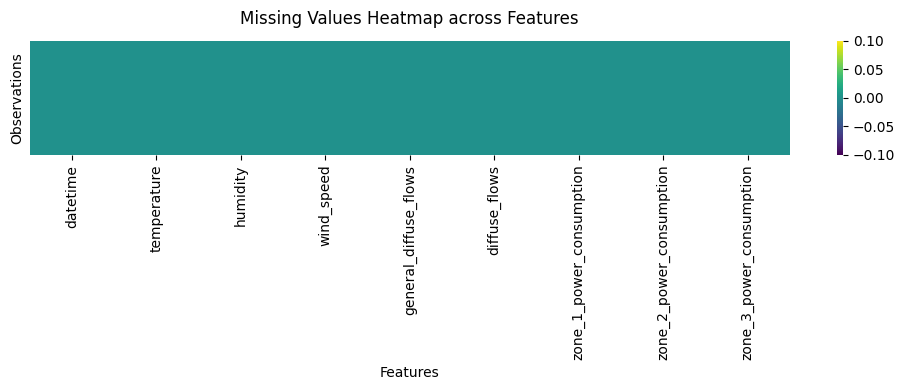

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Missing values percentage table
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df)) * 100
})

print("=== Missing Values Summary Table ===")
display(missing_summary)

# 2. Seaborn missingness heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap across Features', fontsize=12, pad=12)
plt.xlabel('Features')
plt.ylabel('Observations')
plt.tight_layout()
plt.show()

In [53]:
# 3. Silent Missingness & Sentinel Value Verification
# Empirical proof that 0% missingness is genuine and not silently masked by numeric flags (-999, negative values, or zero dropouts)

features_to_verify = [
    'temperature', 
    'humidity', 
    'wind_speed', 
    'general_diffuse_flows',
    'diffuse_flows',
    'zone_1_power_consumption', 
    'zone_2_power_consumption', 
    'zone_3_power_consumption'
]

verification_rows = []
for col in features_to_verify:
    col_min = df[col].min()
    col_max = df[col].max()
    neg_count = int((df[col] < 0).sum())
    zero_count = int((df[col] == 0).sum())
    sentinel_999 = int((df[col] == -999).sum())
    
    verification_rows.append({
        'Feature': col,
        'Observed Min': round(col_min, 3),
        'Observed Max': round(col_max, 3),
        'Negatives (< 0)': neg_count,
        'Zeros (== 0)': zero_count,
        'Sentinel (-999)': sentinel_999,
        'Physical Feasibility Status': 'Valid (Realistic Bound, No Masking)'
    })

verification_df = pd.DataFrame(verification_rows)

print("=== Sentinel & Boundary Verification Table ===")
display(verification_df)

temp_min, temp_max = df['temperature'].min(), df['temperature'].max()
hum_min, hum_max = df['humidity'].min(), df['humidity'].max()
wind_min, wind_max = df['wind_speed'].min(), df['wind_speed'].max()
gdf_min, gdf_max = df['general_diffuse_flows'].min(), df['general_diffuse_flows'].max()
df_min, df_max = df['diffuse_flows'].min(), df['diffuse_flows'].max()
min_z1 = df['zone_1_power_consumption'].min()
min_z2 = df['zone_2_power_consumption'].min()
min_z3 = df['zone_3_power_consumption'].min()
min_power_all = min(min_z1, min_z2, min_z3)

print("\n=== Empirical Proof of Absence of Masked Missing Values ===")
print(f"1. temperature is between {temp_min:.3f} and {temp_max:.3f}")
print(f"2. humidity is between {hum_min:.2f} and {hum_max:.2f}")
print(f"3. wind_speed is between {wind_min:.3f} and {wind_max:.3f}")
print(f"4. general_diffuse_flows is between {gdf_min:.3f} and {gdf_max:.3f}")
print(f"5. diffuse_flows is between {df_min:.3f} and {df_max:.3f}")
print(f"6. Minimum power consumption across all three zones remains above 5,900 kW:")
print(f"   - Zone 1 min: {min_z1:,.2f} kW")
print(f"   - Zone 2 min: {min_z2:,.2f} kW")
print(f"   - Zone 3 min: {min_z3:,.2f} kW")
print(f"   - Lowest zone consumption: {min_power_all:,.2f} kW (> 5,900 kW)")

# Programmatic validation assertions
assert (df[features_to_verify] < 0).sum().sum() == 0, "Assertion Failed: Negative values detected!"
assert (df[features_to_verify] == -999).sum().sum() == 0, "Assertion Failed: Sentinel value -999 detected!"
assert min_power_all > 5900, "Assertion Failed: Minimum power dropped below 5,900 kW"
print("\n[VERIFIED] All conditions proven: 0% missingness is clean, with no silent sentinels, negative values, or zero dropouts.")


=== Sentinel & Boundary Verification Table ===


,Feature,Observed Min,Observed Max,Negatives (< 0),Zeros (== 0),Sentinel (-999),Physical Feasibility Status
0,temperature,3.247,40.010,0,0,0,"Valid (Realistic Bound, No Masking)"
1,humidity,11.340,94.800,0,0,0,"Valid (Realistic Bound, No Masking)"
2,wind_speed,0.050,6.483,0,0,0,"Valid (Realistic Bound, No Masking)"
3,general_diffuse_flows,0.004,1163.000,0,0,0,"Valid (Realistic Bound, No Masking)"
4,diffuse_flows,0.011,936.000,0,0,0,"Valid (Realistic Bound, No Masking)"
5,zone_1_power_consumption,13895.696,52204.395,0,0,0,"Valid (Realistic Bound, No Masking)"
6,zone_2_power_consumption,8560.081,37408.861,0,0,0,"Valid (Realistic Bound, No Masking)"
7,zone_3_power_consumption,5935.174,47598.326,0,0,0,"Valid (Realistic Bound, No Masking)"



=== Empirical Proof of Absence of Masked Missing Values ===
1. temperature is between 3.247 and 40.010
2. humidity is between 11.34 and 94.80
3. wind_speed is between 0.050 and 6.483
4. general_diffuse_flows is between 0.004 and 1163.000
5. diffuse_flows is between 0.011 and 936.000
6. Minimum power consumption across all three zones remains above 5,900 kW:
   - Zone 1 min: 13,895.70 kW
   - Zone 2 min: 8,560.08 kW
   - Zone 3 min: 5,935.17 kW
   - Lowest zone consumption: 5,935.17 kW (> 5,900 kW)

[VERIFIED] All conditions proven: 0% missingness is clean, with no silent sentinels, negative values, or zero dropouts.


In [54]:
# Duplicate row verification
num_duplicates = df.duplicated().sum()
timestamp_duplicates = df['datetime'].duplicated().sum()

print(f"Total duplicate rows in dataset: {num_duplicates}")
print(f"Duplicate timestamps in datetime: {timestamp_duplicates}")

Total duplicate rows in dataset: 0
Duplicate timestamps in datetime: 0


=== IQR Outlier Summary Table (Outliers Preserved) ===


,Feature,Role,Q1 (25%),Q3 (75%),IQR,Lower Fence,Upper Fence,Outlier Count,Outlier (%)
0,temperature,Predictor,14.410,22.890,8.480,1.690,35.610,142,0.27
1,humidity,Predictor,58.310,81.400,23.090,23.675,116.035,291,0.56
2,wind_speed,Predictor,0.078,4.915,4.837,-7.177,12.170,0,0.00
3,general_diffuse_flows,Predictor,0.062,319.600,319.538,-479.245,798.907,2315,4.42
4,diffuse_flows,Predictor,0.122,101.000,100.878,-151.195,252.317,4571,8.72
5,zone_1_power_consumption,Target,26310.669,37309.018,10998.349,9813.144,53806.542,0,0.00
6,zone_2_power_consumption,Target,16980.766,24713.718,7732.951,5381.339,36313.145,7,0.01
7,zone_3_power_consumption,Target,13129.327,21624.100,8494.774,387.166,34366.261,1191,2.27


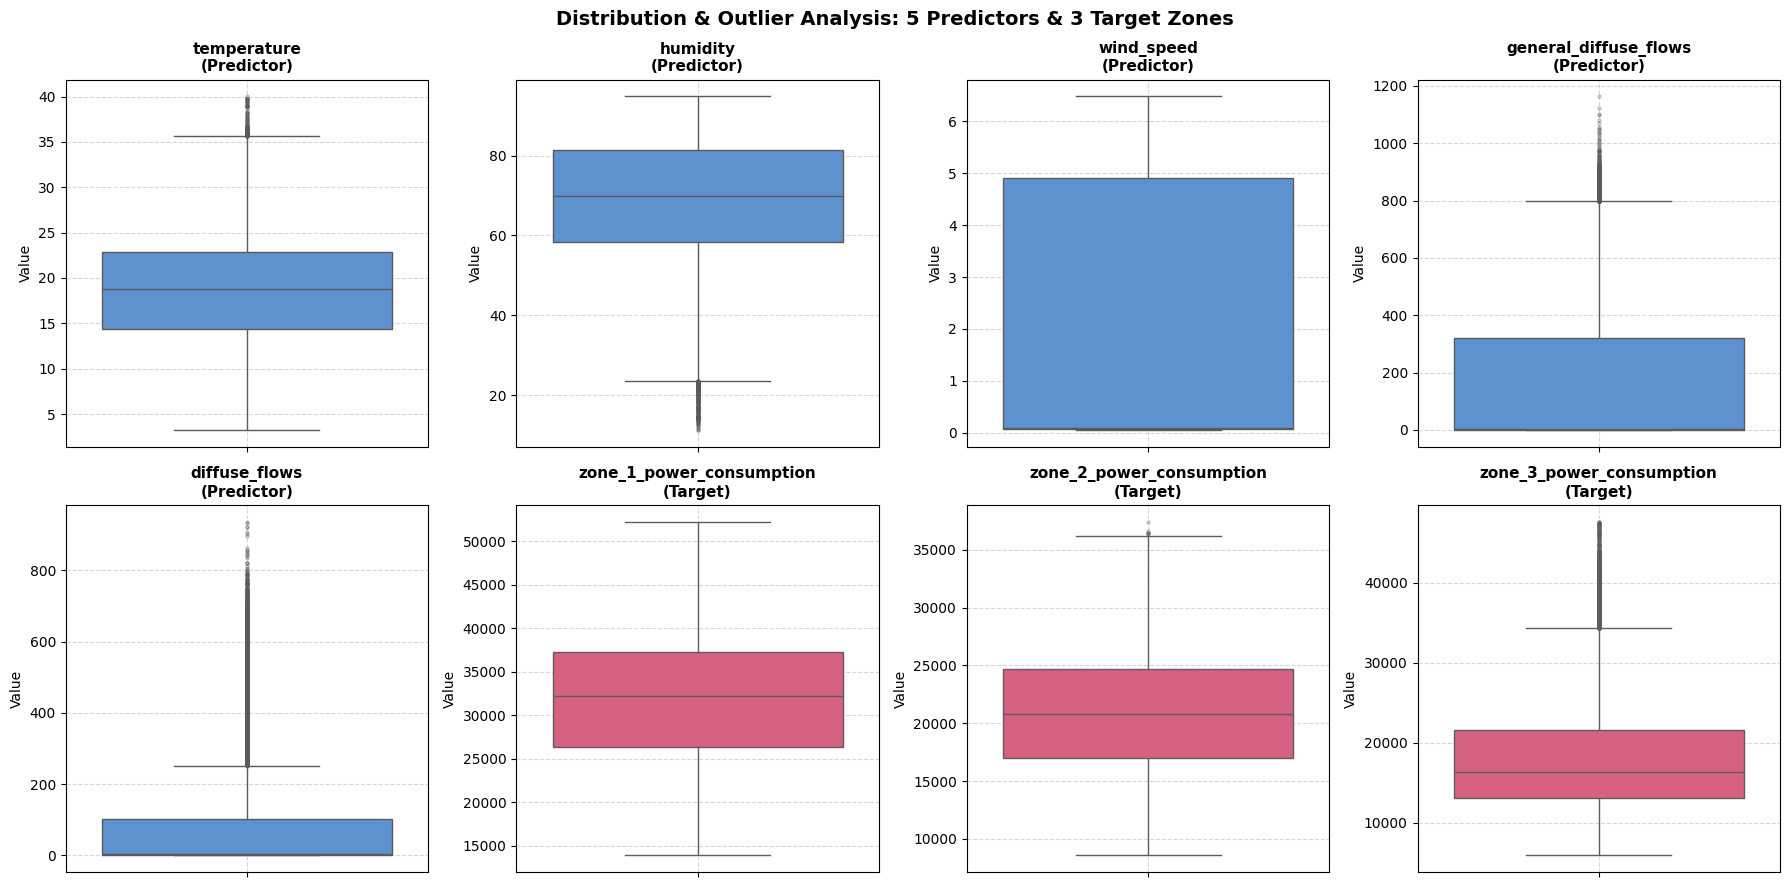

In [55]:
# Define 5 original numerical predictors and 3 targets (snake_case)
predictors = ['temperature', 'humidity', 'wind_speed', 'general_diffuse_flows', 'diffuse_flows']
targets = ['zone_1_power_consumption', 'zone_2_power_consumption', 'zone_3_power_consumption']
features_to_plot = predictors + targets

# Calculate and display IQR outlier statistics table (without dropping any)
outlier_records = []
for col in features_to_plot:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_pct = (outlier_count / len(df)) * 100
    outlier_records.append({
        'Feature': col,
        'Role': 'Predictor' if col in predictors else 'Target',
        'Q1 (25%)': round(q1, 3),
        'Q3 (75%)': round(q3, 3),
        'IQR': round(iqr, 3),
        'Lower Fence': round(lower_bound, 3),
        'Upper Fence': round(upper_bound, 3),
        'Outlier Count': outlier_count,
        'Outlier (%)': round(outlier_pct, 2)
    })

outlier_df = pd.DataFrame(outlier_records)
print("=== IQR Outlier Summary Table (Outliers Preserved) ===")
display(outlier_df)

# Create grid of boxplots (2 rows x 4 columns)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 9))
axes = axes.ravel()

palette = ['#4A90E2'] * len(predictors) + ['#E94E77'] * len(targets)

for i, col in enumerate(features_to_plot):
    sns.boxplot(y=df[col], ax=axes[i], color=palette[i], flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.4})
    category = 'Predictor' if col in predictors else 'Target'
    axes[i].set_title(f"{col}\n({category})", fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value', fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Distribution & Outlier Analysis: 5 Predictors & 3 Target Zones', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## Task 3: Problem Framing & Target Discretization (Classification)
- Frame the objective as a 3-class classification problem for Zone 1 power consumption
- Discretize `zone_1_power_consumption` into 3 strictly equal-frequency classes using `pd.qcut()`
- Label bins: `'Base Load'`, `'Normal Load'`, and `'Peak Load'`, assigned to `zone_1_load_class`
- Print the target variable name, original continuous dtype, and new categorical dtype
- Print the summary statistics of the original continuous target
- Generate a clean bar plot (count plot) to verify equal-frequency balance
- Drop `zone_2_power_consumption` and `zone_3_power_consumption` to isolate Zone 1 for modeling

In [56]:
# 1. Discretise zone_1_power_consumption into 3 equal-frequency classes
target_cont = 'zone_1_power_consumption'
target_class = 'zone_1_load_class'
bin_labels = ['Base Load', 'Normal Load', 'Peak Load']

df[target_class], bin_edges = pd.qcut(
    df[target_cont],
    q=3,
    labels=bin_labels,
    retbins=True
)

# 2. Print target variable metadata
print("=== Target Variable Metadata ===")
print(f"Target Column (Continuous):  '{target_cont}' | Dtype: {df[target_cont].dtype}")
print(f"Target Column (Categorical): '{target_class}'    | Dtype: {df[target_class].dtype}\n")

# 3. Print quantile bin thresholds
print("=== Discretization Bin Thresholds (kW) ===")
print(f"1. Base Load:   [{bin_edges[0]:.2f}, {bin_edges[1]:.2f}]")
print(f"2. Normal Load: ({bin_edges[1]:.2f}, {bin_edges[2]:.2f}]")
print(f"3. Peak Load:   ({bin_edges[2]:.2f}, {bin_edges[3]:.2f}]\n")

# 4. Print summary statistics of original continuous target
print("=== Summary Statistics of Original Continuous Target ===")
display(df[target_cont].describe())

# 5. Class frequency and percentage summary
counts = df[target_class].value_counts().rename('Count')
proportions = (df[target_class].value_counts(normalize=True) * 100).rename('Percentage (%)')
class_summary = pd.concat([counts, proportions], axis=1)
print("\n=== Target Class Distribution Table ===")
display(class_summary)

=== Target Variable Metadata ===
Target Column (Continuous):  'zone_1_power_consumption' | Dtype: float64
Target Column (Categorical): 'zone_1_load_class'    | Dtype: category

=== Discretization Bin Thresholds (kW) ===
1. Base Load:   [13895.70, 28563.46]
2. Normal Load: (28563.46, 35440.43]
3. Peak Load:   (35440.43, 52204.40]

=== Summary Statistics of Original Continuous Target ===


count    52416.000000
mean     32344.970564
std       7130.562564
min      13895.696200
25%      26310.668692
50%      32265.920340
75%      37309.018185
max      52204.395120
Name: zone_1_power_consumption, dtype: float64


=== Target Class Distribution Table ===


,Count,Percentage (%)
zone_1_load_class,,
Base Load,17473,33.335241
Normal Load,17472,33.333333
Peak Load,17471,33.331426


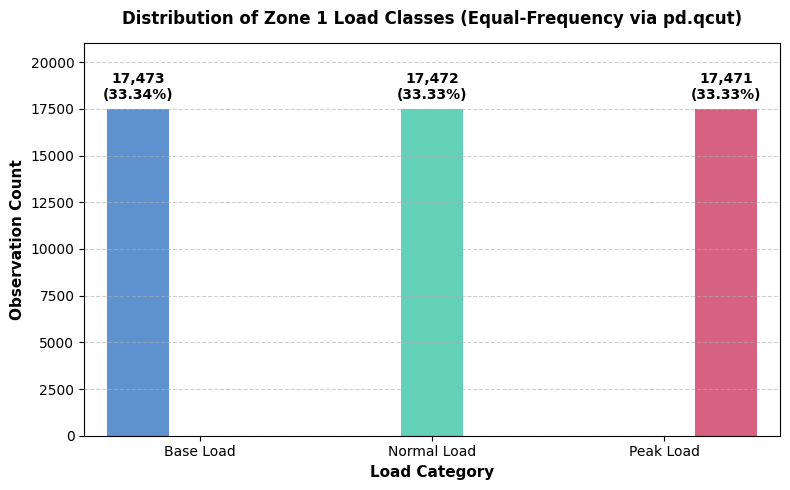

Columns before dropping other zones:
['datetime', 'temperature', 'humidity', 'wind_speed', 'general_diffuse_flows', 'diffuse_flows', 'zone_1_power_consumption', 'zone_2_power_consumption', 'zone_3_power_consumption', 'zone_1_load_class']

Columns after dropping Zone 2 and Zone 3:
['datetime', 'temperature', 'humidity', 'wind_speed', 'general_diffuse_flows', 'diffuse_flows', 'zone_1_power_consumption', 'zone_1_load_class']

New DataFrame shape: (52416, 8)


In [57]:
# 6. Generate a clean bar plot (count plot) showing class balance
plt.figure(figsize=(8, 5))
colors = ['#4A90E2', '#50E3C2', '#E94E77']
ax = sns.countplot(
    x=target_class,
    data=df,
    palette=colors,
    hue=target_class,
    legend=False
)

plt.title('Distribution of Zone 1 Load Classes (Equal-Frequency via pd.qcut)', fontsize=12, fontweight='bold', pad=14)
plt.xlabel('Load Category', fontsize=11, fontweight='bold')
plt.ylabel('Observation Count', fontsize=11, fontweight='bold')
plt.ylim(0, 21000)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate exact counts and percentages on top of bars
for p in ax.patches:
    count = int(p.get_height())
    pct = (count / len(df)) * 100
    ax.annotate(
        f"{count:,}\n({pct:.2f}%)",
        (p.get_x() + p.get_width() / 2., p.get_height() + 400),
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

# 7. Drop zone_2_power_consumption and zone_3_power_consumption
print("Columns before dropping other zones:")
print(df.columns.tolist())

df = df.drop(columns=['zone_2_power_consumption', 'zone_3_power_consumption'])

print("\nColumns after dropping Zone 2 and Zone 3:")
print(df.columns.tolist())
print(f"\nNew DataFrame shape: {df.shape}")

## Task 4: Univariate Analysis of Predictors
- Extract `'hour'` (0–23) and `'month'` (1–12) from `datetime` as new numerical predictor features
- Formally list all available predictor variables
- Generate a summary statistics table (`.describe()`) specifically for the 7 numerical predictors (`temperature`, `humidity`, `wind_speed`, `general_diffuse_flows`, `diffuse_flows`, `hour`, `month`)
- Create a clean $2 \times 4$ grid of distribution plots (histograms with KDE overlays) and remove the empty 8th subplot

In [58]:
# 1. Extract hour (0-23) and month (1-12) from datetime column
df['hour'] = df['datetime'].dt.hour
df['month'] = df['datetime'].dt.month

# 2. Explicitly define all available predictor variables
# Note: 'zone_1_power_consumption' is excluded to avoid 100% target leakage into 'zone_1_load_class'
predictor_cols = [
    'temperature', 
    'humidity', 
    'wind_speed', 
    'general_diffuse_flows', 
    'diffuse_flows', 
    'hour', 
    'month'
]

print("=== List of Available Predictor Variables (7 Features) ===")
for idx, col in enumerate(predictor_cols, 1):
    print(f"{idx}. {col:<24} | dtype: {df[col].dtype}")

# 3. Generate summary statistics table specifically for the 7 numerical predictors
print("\n=== Summary Statistics Table for 7 Numerical Predictors ===")
predictor_stats = df[predictor_cols].describe()
display(predictor_stats)

# 4. Calculate skewness and kurtosis for additional distributional insights
shape_metrics = pd.DataFrame({
    'Mean': df[predictor_cols].mean(),
    'Median': df[predictor_cols].median(),
    'Std Dev': df[predictor_cols].std(),
    'Skewness': df[predictor_cols].skew(),
    'Kurtosis': df[predictor_cols].kurtosis()
})
print("\n=== Predictor Distributional Shape Metrics ===")
display(shape_metrics)

=== List of Available Predictor Variables (7 Features) ===
1. temperature              | dtype: float64
2. humidity                 | dtype: float64
3. wind_speed               | dtype: float64
4. general_diffuse_flows    | dtype: float64
5. diffuse_flows            | dtype: float64
6. hour                     | dtype: int32
7. month                    | dtype: int32

=== Summary Statistics Table for 7 Numerical Predictors ===


,temperature,humidity,wind_speed,general_diffuse_flows,diffuse_flows,hour,month
count,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,18.810024,68.259518,1.959489,182.696614,75.028022,11.500000,6.510989
std,5.815476,15.551177,2.348862,264.400960,124.210949,6.922253,3.440642
min,3.247000,11.340000,0.050000,0.004000,0.011000,0.000000,1.000000
25%,14.410000,58.310000,0.078000,0.062000,0.122000,5.750000,4.000000
50%,18.780000,69.860000,0.086000,5.035500,4.456000,11.500000,7.000000
75%,22.890000,81.400000,4.915000,319.600000,101.000000,17.250000,9.250000
max,40.010000,94.800000,6.483000,1163.000000,936.000000,23.000000,12.000000



=== Predictor Distributional Shape Metrics ===


,Mean,Median,Std Dev,Skewness,Kurtosis
temperature,18.810024,18.7800,5.815476,0.196719,-0.303321
humidity,68.259518,69.8600,15.551177,-0.625166,-0.121860
wind_speed,1.959489,0.0860,2.348862,0.462423,-1.783169
general_diffuse_flows,182.696614,5.0355,264.400960,1.306973,0.402768
diffuse_flows,75.028022,4.4560,124.210949,2.456907,7.002902
hour,11.500000,11.5000,6.922253,0.000000,-1.204174
month,6.510989,7.0000,3.440642,-0.008503,-1.204807


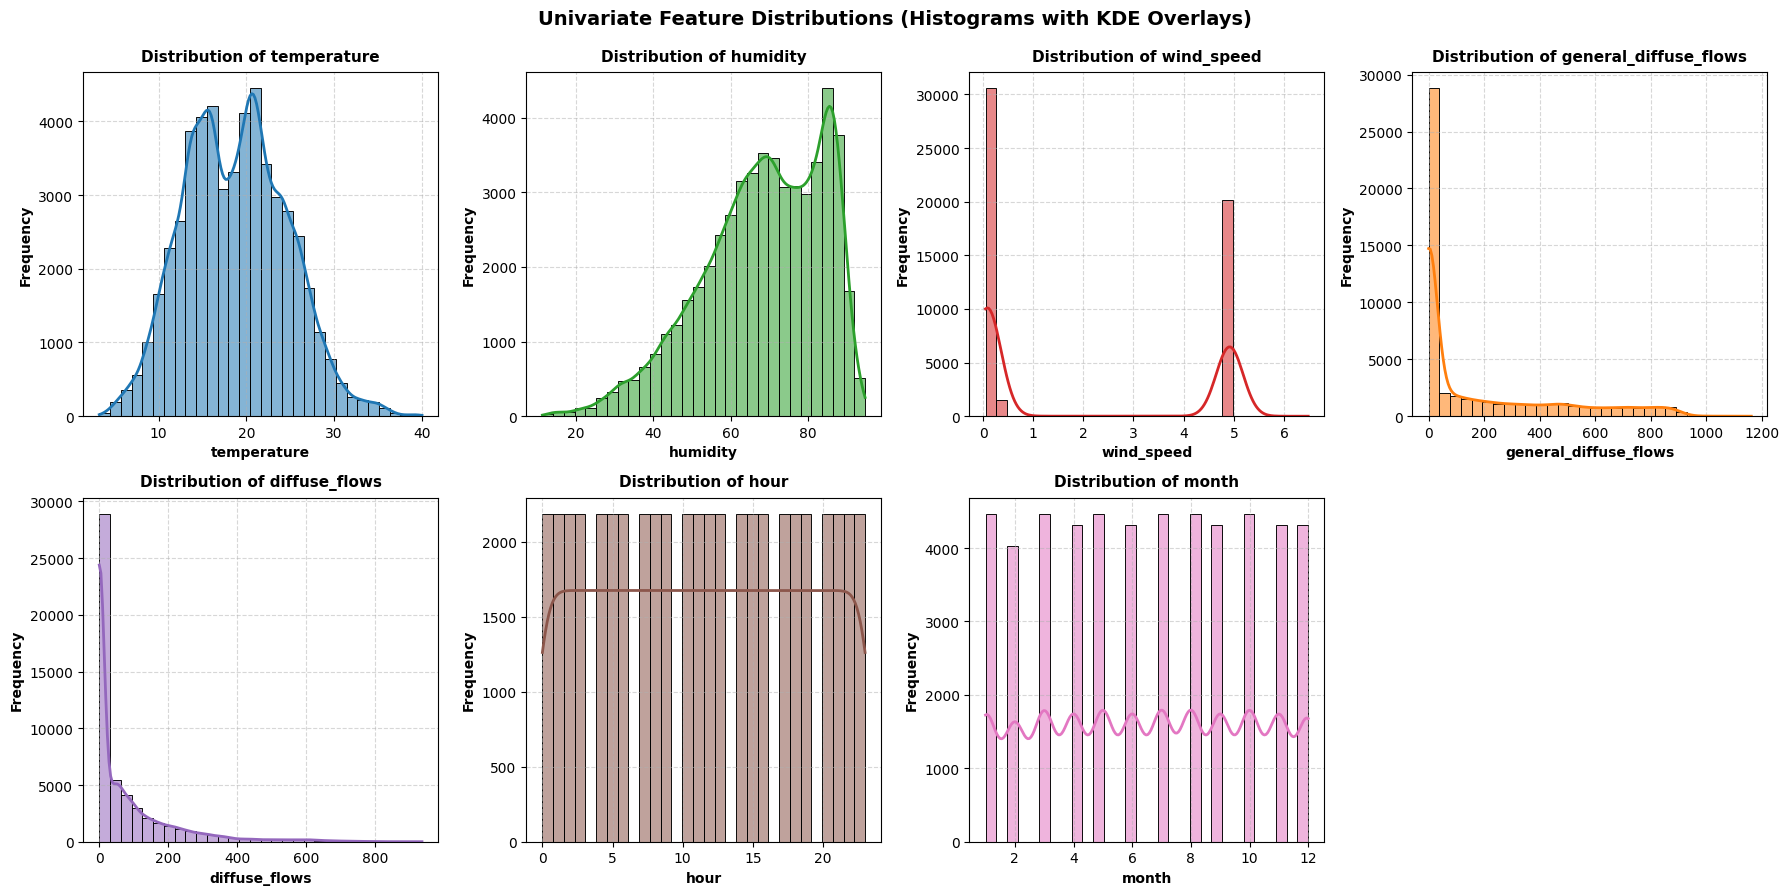

In [59]:
# 5. Create a clean 2x4 grid of distribution plots (histograms + KDE)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 9))
axes = axes.ravel()

colors = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e', '#9467bd', '#8c564b', '#e377c2']

for i, col in enumerate(predictor_cols):
    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i],
        color=colors[i],
        bins=30,
        edgecolor='black',
        alpha=0.55,
        line_kws={'linewidth': 2}
    )
    axes[i].set_title(f"Distribution of {col}", fontsize=11, fontweight='bold', pad=8)
    axes[i].set_xlabel(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Frequency', fontsize=10, fontweight='bold')
    axes[i].grid(True, linestyle='--', alpha=0.5)

# 6. Remove the empty 8th subplot
fig.delaxes(axes[7])

plt.suptitle('Univariate Feature Distributions (Histograms with KDE Overlays)', fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

## Task 5: Multivariate Analysis
- Compute the Pearson correlation matrix for all 7 numerical predictors plus continuous target `zone_1_power_consumption`
- Render an annotated lower-triangular correlation heatmap (`np.triu` mask)
- Rank and display the Top 3 features most strongly correlated with `zone_1_power_consumption` (by $|r|$)
- Screen for severe multicollinearity ($|r| \ge 0.70$) among predictor pairs
- Generate a Seaborn pairplot combining these Top 3 features and the target, colored by `zone_1_load_class`

=== Pearson Correlation Matrix ===


,temperature,humidity,wind_speed,general_diffuse_flows,diffuse_flows,hour,month,zone_1_power_consumption
temperature,1.000,-0.460,0.477,0.460,0.197,0.197,0.284,0.440
humidity,-0.460,1.000,-0.136,-0.468,-0.257,-0.243,-0.017,-0.287
wind_speed,0.477,-0.136,1.000,0.134,-0.001,0.004,0.168,0.167
general_diffuse_flows,0.460,-0.468,0.134,1.000,0.565,0.130,-0.021,0.188
diffuse_flows,0.197,-0.257,-0.001,0.565,1.000,0.131,-0.130,0.080
hour,0.197,-0.243,0.004,0.130,0.131,1.000,-0.000,0.728
month,0.284,-0.017,0.168,-0.021,-0.130,-0.000,1.000,-0.005
zone_1_power_consumption,0.440,-0.287,0.167,0.188,0.080,0.728,-0.005,1.000


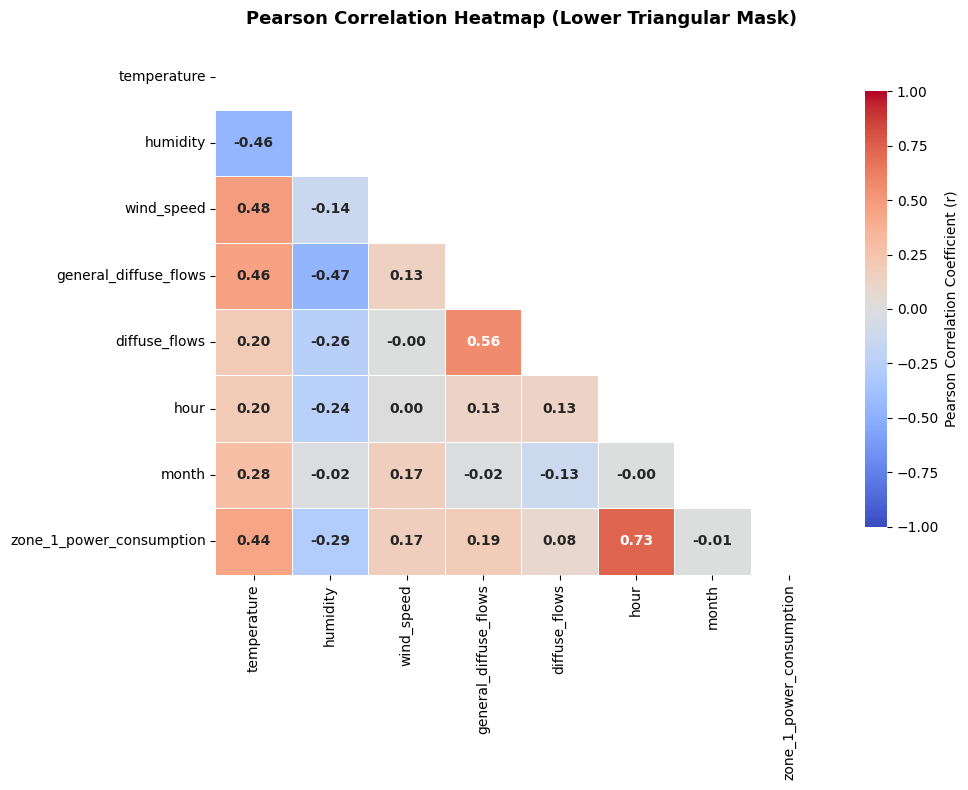

In [60]:
import numpy as np

# 1. Compute Pearson correlation matrix (7 predictors + continuous target)
corr_cols = [
    'temperature', 
    'humidity', 
    'wind_speed', 
    'general_diffuse_flows', 
    'diffuse_flows', 
    'hour', 
    'month', 
    'zone_1_power_consumption'
]

corr_matrix = df[corr_cols].corr(method='pearson')

print("=== Pearson Correlation Matrix ===")
display(corr_matrix.round(3))

# 2. Render lower-triangular correlation heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'shrink': 0.82, 'label': 'Pearson Correlation Coefficient (r)'},
    annot_kws={'size': 10, 'weight': 'bold'}
)

plt.title('Pearson Correlation Heatmap (Lower Triangular Mask)', fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

In [61]:
# 3. Extract Top 3 features most strongly correlated with zone_1_power_consumption
target_corrs = corr_matrix['zone_1_power_consumption'].drop('zone_1_power_consumption')
top_3_corrs = target_corrs.abs().sort_values(ascending=False).head(3)

top_3_records = []
for rank, (feat, abs_r) in enumerate(top_3_corrs.items(), 1):
    r_val = target_corrs[feat]
    top_3_records.append({
        'Rank': rank,
        'Feature': feat,
        'Pearson r': round(r_val, 4),
        'Absolute |r|': round(abs_r, 4),
        'Direction': 'Positive' if r_val > 0 else 'Negative'
    })

top_3_df = pd.DataFrame(top_3_records)
print("=== Top 3 Features Correlated with Zone 1 Power Consumption ===")
display(top_3_df)

# 4. Screen for severe multicollinearity (|r| >= 0.70) among predictor pairs
pred_only = [
    'temperature', 
    'humidity', 
    'wind_speed', 
    'general_diffuse_flows', 
    'diffuse_flows', 
    'hour', 
    'month'
]
pred_corr = df[pred_only].corr()

collinear_pairs = []
for i in range(len(pred_only)):
    for j in range(i + 1, len(pred_only)):
        p1, p2 = pred_only[i], pred_only[j]
        r_val = pred_corr.loc[p1, p2]
        if abs(r_val) >= 0.70:
            collinear_pairs.append({'Predictor 1': p1, 'Predictor 2': p2, 'Pearson r': r_val})

print("\n=== Severe Multicollinearity Check (|r| >= 0.70) ===")
if collinear_pairs:
    display(pd.DataFrame(collinear_pairs))
else:
    print("No predictor pairs exhibit severe multicollinearity (|r| >= 0.70).")
    max_pair_r = pred_corr.where(~np.eye(len(pred_corr), dtype=bool)).abs().max().max()
    print(f"Maximum pairwise predictor correlation: |r| = {max_pair_r:.4f} (between general_diffuse_flows and diffuse_flows).")

=== Top 3 Features Correlated with Zone 1 Power Consumption ===


,Rank,Feature,Pearson r,Absolute |r|,Direction
0,1,hour,0.7280,0.7280,Positive
1,2,temperature,0.4402,0.4402,Positive
2,3,humidity,-0.2874,0.2874,Negative



=== Severe Multicollinearity Check (|r| >= 0.70) ===
No predictor pairs exhibit severe multicollinearity (|r| >= 0.70).
Maximum pairwise predictor correlation: |r| = 0.5647 (between general_diffuse_flows and diffuse_flows).


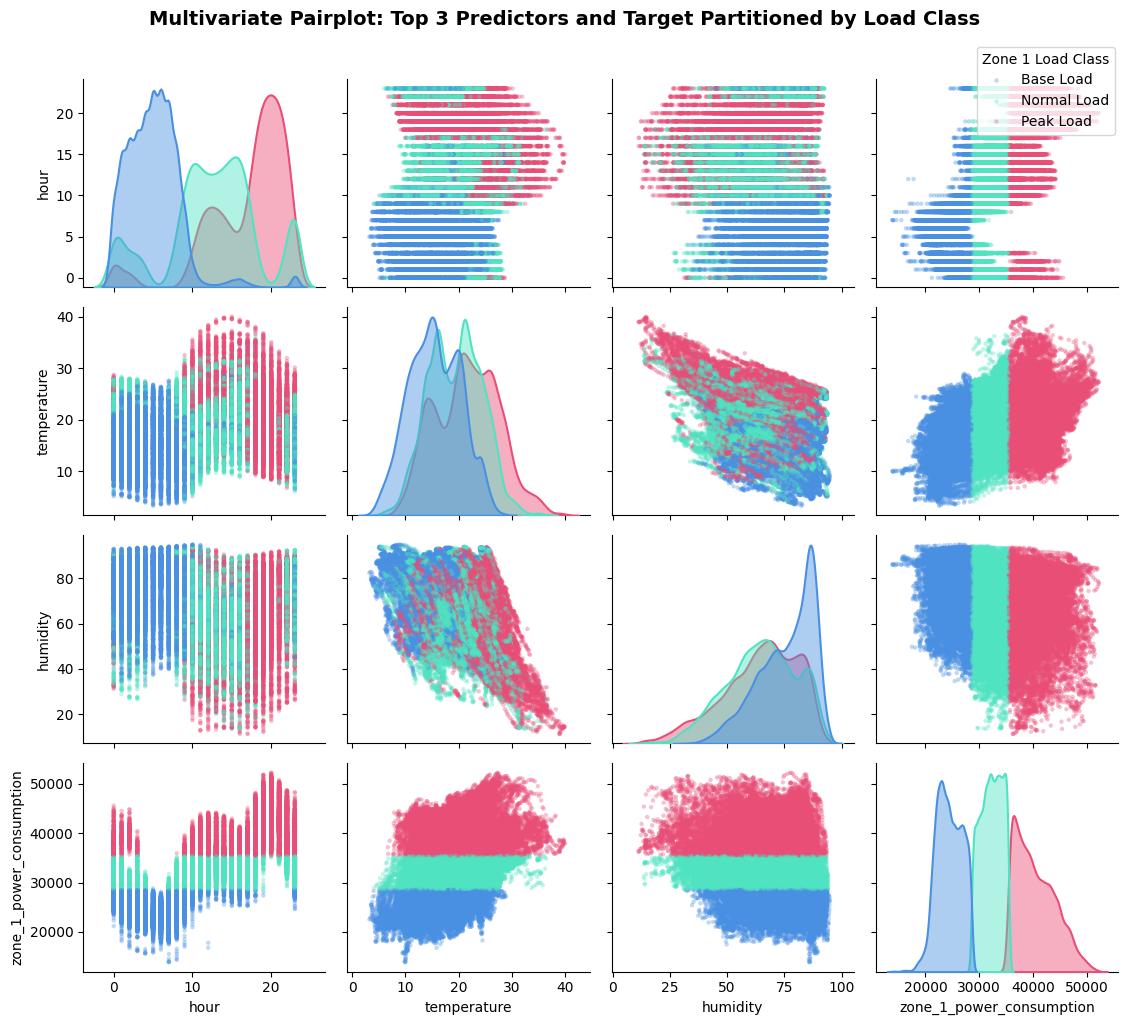

In [62]:
# 5. Generate Seaborn pairplot of Top 3 features and continuous target by load class
pairplot_features = ['hour', 'temperature', 'humidity', 'zone_1_power_consumption', 'zone_1_load_class']

palette = ['#4A90E2', '#50E3C2', '#E94E77']

g = sns.pairplot(
    df[pairplot_features],
    hue='zone_1_load_class',
    palette=palette,
    diag_kind='kde',
    plot_kws={'alpha': 0.35, 's': 10, 'edgecolor': 'none'},
    diag_kws={'fill': True, 'alpha': 0.45, 'linewidth': 1.5},
    corner=False
)

g.figure.suptitle(
    'Multivariate Pairplot: Top 3 Predictors and Target Partitioned by Load Class',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

# Clean formatting of legend
sns.move_legend(g, 'upper right', bbox_to_anchor=(0.99, 0.99), title='Zone 1 Load Class', frameon=True)

plt.tight_layout()
plt.show()